<a href="https://colab.research.google.com/github/sauravv-kunwar/100-days-of-ML/blob/main/Overfitting_Underfitting_in_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

### Overfitting and Underfitting in Decision Trees

**Overfitting** occurs when a model learns the training data too well, including the noise and outliers, leading to poor generalization on unseen data. In decision trees, this often happens when the tree is allowed to grow too deep (e.g., high `max_depth`), creating overly complex decision boundaries that fit the training points perfectly but fail to capture the true underlying patterns.

**Underfitting** occurs when a model is too simple to capture the underlying patterns in the training data. This results in poor performance on both training and unseen data. In decision trees, this can happen when the tree is too shallow (e.g., low `max_depth`), leading to overly simplistic decision boundaries that cannot separate the different classes effectively.

First, let's generate some synthetic data that will allow us to clearly visualize these concepts. We'll use `make_moons` to create a non-linearly separable dataset.

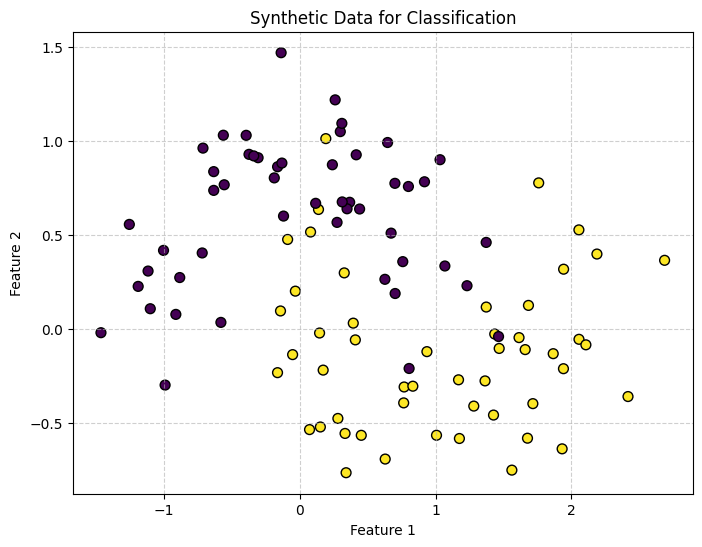

In [2]:
from sklearn.datasets import make_moons

# Generate synthetic data
X, y = make_moons(n_samples=100, noise=0.25, random_state=42)

# Visualize the generated data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis', edgecolors='k')
plt.title('Synthetic Data for Classification')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Next, we'll define a helper function to visualize the decision boundaries of our decision tree models on a mesh grid. This will help us clearly see how the model classifies different regions of the feature space.

In [3]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis', edgecolors='k')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

### 1. Demonstrating Underfitting (Low `max_depth`)

Let's train a decision tree with a very small `max_depth` (e.g., `max_depth=2`). This will create a very simple model that likely won't capture the complexity of the data, leading to underfitting.

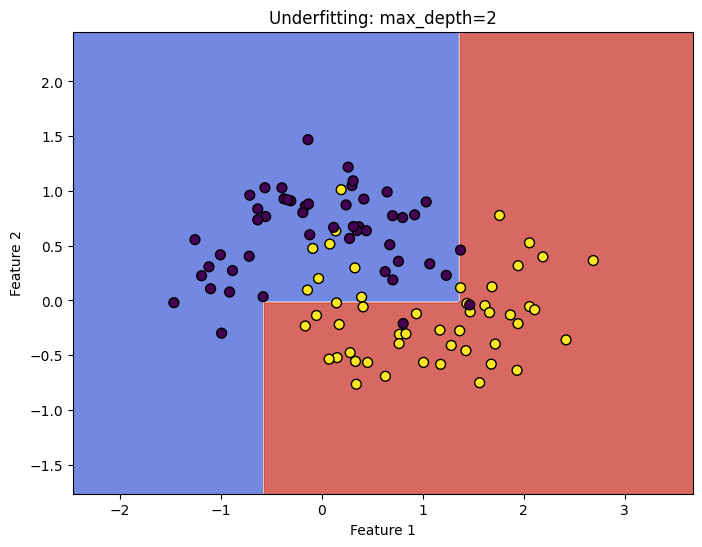

Underfit Model Accuracy: 0.90


In [4]:
# Underfitting: Small max_depth
decision_tree_underfit = DecisionTreeClassifier(max_depth=2, random_state=42)
decision_tree_underfit.fit(X, y)

plot_decision_boundary(decision_tree_underfit, X, y, 'Underfitting: max_depth=2')

print(f"Underfit Model Accuracy: {decision_tree_underfit.score(X, y):.2f}")

As you can see, with `max_depth=2`, the decision boundary is very simple and fails to separate the two 'moon' shapes effectively. The model is too simple for the data.

### 2. Demonstrating Overfitting (High `max_depth` or `None`)

Now, let's train a decision tree with a very large `max_depth` (or by setting `max_depth=None`, which allows the tree to expand until all leaves are pure or contain less than `min_samples_split` samples). This will create a highly complex model that perfectly fits the training data, including noise, leading to overfitting.

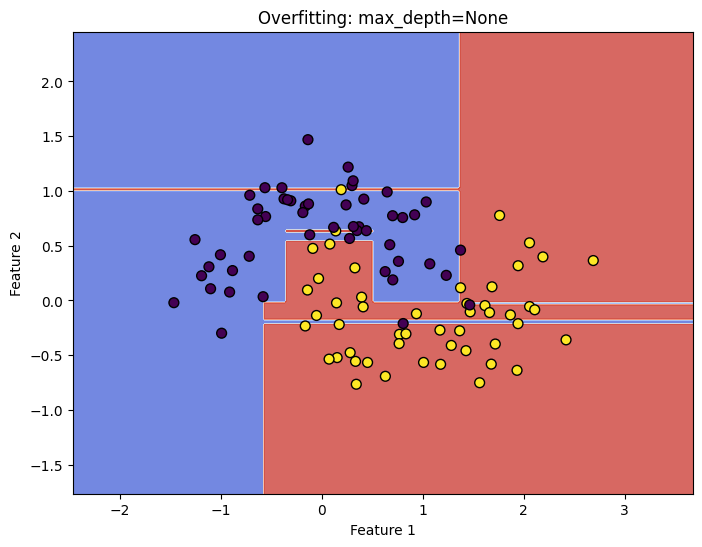

Overfit Model Accuracy: 1.00


In [5]:
# Overfitting: Large max_depth (or None)
decision_tree_overfit = DecisionTreeClassifier(max_depth=None, random_state=42) # Let it grow fully
decision_tree_overfit.fit(X, y)

plot_decision_boundary(decision_tree_overfit, X, y, 'Overfitting: max_depth=None')

print(f"Overfit Model Accuracy: {decision_tree_overfit.score(X, y):.2f}")

Notice how the decision boundary is extremely jagged and attempts to encapsulate every single training point perfectly. While the training accuracy might be very high (or even 1.0), this model is likely to perform poorly on new, unseen data because it has learned the noise rather than the general pattern.

### 3. Demonstrating a Well-Fitted Model (Optimal `max_depth`)

Finally, let's find a `max_depth` that provides a good balance between bias and variance, leading to a well-generalized model. For this specific synthetic dataset, a `max_depth` around 5 or 6 usually works well.

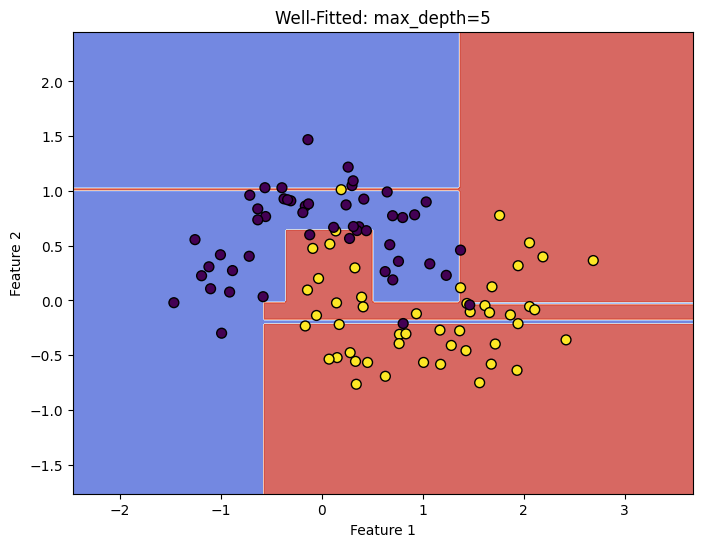

Well-Fitted Model Accuracy: 0.98


In [6]:
# Well-fitted: Optimal max_depth
decision_tree_wellfit = DecisionTreeClassifier(max_depth=5, random_state=42)
decision_tree_wellfit.fit(X, y)

plot_decision_boundary(decision_tree_wellfit, X, y, 'Well-Fitted: max_depth=5')

print(f"Well-Fitted Model Accuracy: {decision_tree_wellfit.score(X, y):.2f}")

This model creates a smoother decision boundary that still captures the main structure of the 'moon' shapes without being overly complex or overly simple. This `max_depth` value represents a better trade-off, leading to a model that generalizes better to unseen data.